Test Wallahi

In [3]:
#import the cleaned data.

#the real function will get the df fed as input from the clean function

import pandas as pd
import matplotlib.pyplot as plt
from clean_emi_data import clean_demand_per_zone

save_path = 'data_output/demand_preprocessed.csv'

df = clean_demand_per_zone()

Empty DataFrame
Columns: [demand_GWh_CNI, demand_GWh_LNI, demand_GWh_LSI, demand_GWh_UNI, demand_GWh_USI]
Index: []
✅ demand has been cleaned and saved under data_output/demand_utc12.csv ✅


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217390 entries, 0 to 217389
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   datetime        217390 non-null  datetime64[ns]
 1   demand_GWh_CNI  217320 non-null  float64       
 2   demand_GWh_LNI  217311 non-null  float64       
 3   demand_GWh_LSI  217289 non-null  float64       
 4   demand_GWh_UNI  217303 non-null  float64       
 5   demand_GWh_USI  217297 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 10.0 MB


In [9]:
df['hour_bucket'] = (
    df['datetime'] + pd.Timedelta(minutes=30)
).dt.floor('h')

df_hourly_demand = (
    df
    .groupby('hour_bucket')
    .agg(
        datetime_utc12  = ('datetime',        'max'),
        demand_GWh_CNI  = ('demand_GWh_CNI',  'sum'),
        demand_GWh_LNI  = ('demand_GWh_LNI',  'sum'),
        demand_GWh_LSI  = ('demand_GWh_LSI',  'sum'),
        demand_GWh_UNI  = ('demand_GWh_UNI',  'sum'),
        demand_GWh_USI  = ('demand_GWh_USI',  'sum'),
    )
    .reset_index(drop=True)
    .sort_values('datetime_utc12')
    .reset_index(drop=True)
)

In [7]:
df_hourly_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108709 entries, 0 to 108708
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   datetime_utc12  108709 non-null  datetime64[ns]
 1   CNI             108709 non-null  float64       
 2   LNI             108709 non-null  float64       
 3   LSI             108709 non-null  float64       
 4   UNI             108709 non-null  float64       
 5   USI             108709 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 5.0 MB


In [8]:
df_hourly_demand.head()


,datetime_utc12,CNI,LNI,LSI,UNI,USI
0,2013-12-31 23:00:00,0.368,0.216,0.452,0.449,0.226
1,2014-01-01 00:00:00,0.706,0.402,0.888,0.868,0.426
2,2014-01-01 01:00:00,0.673,0.374,0.870,0.818,0.375
3,2014-01-01 02:00:00,0.639,0.362,0.856,0.778,0.347
4,2014-01-01 03:00:00,0.629,0.356,0.853,0.762,0.338


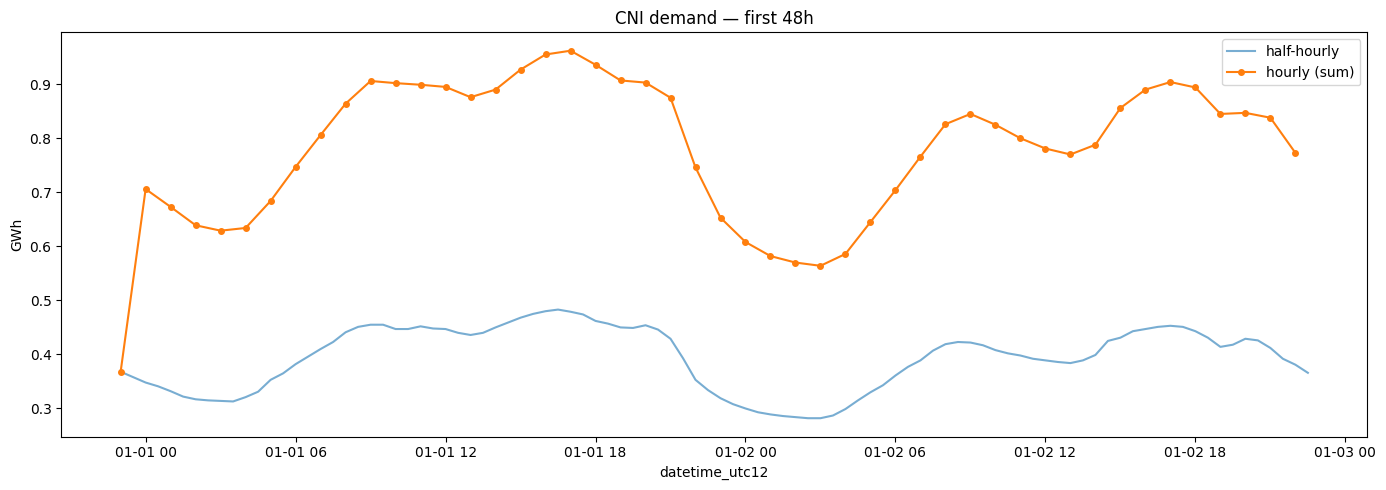

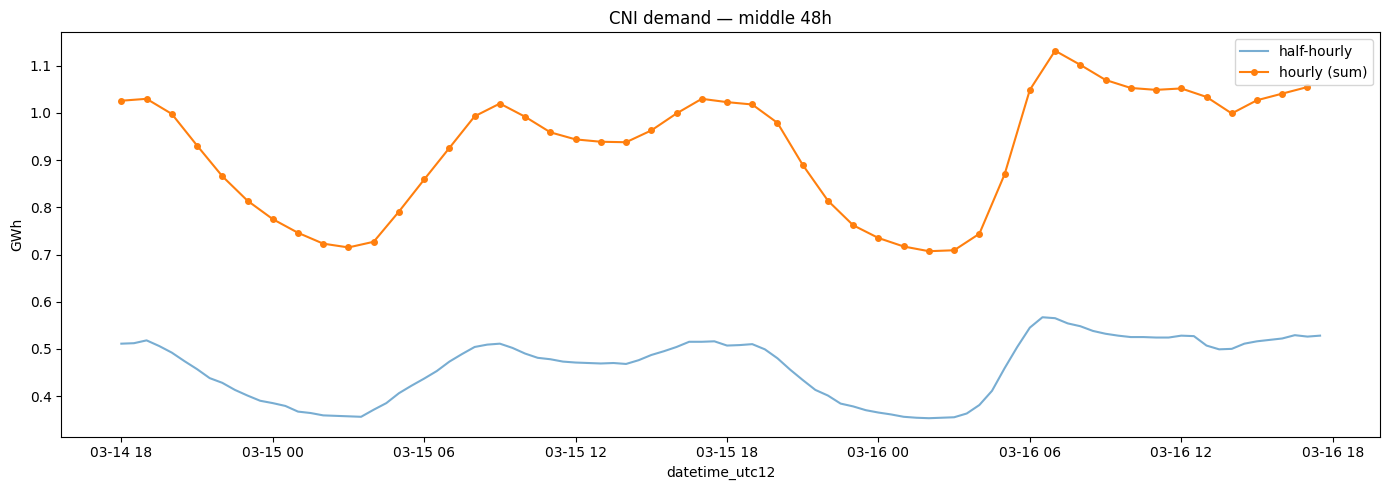

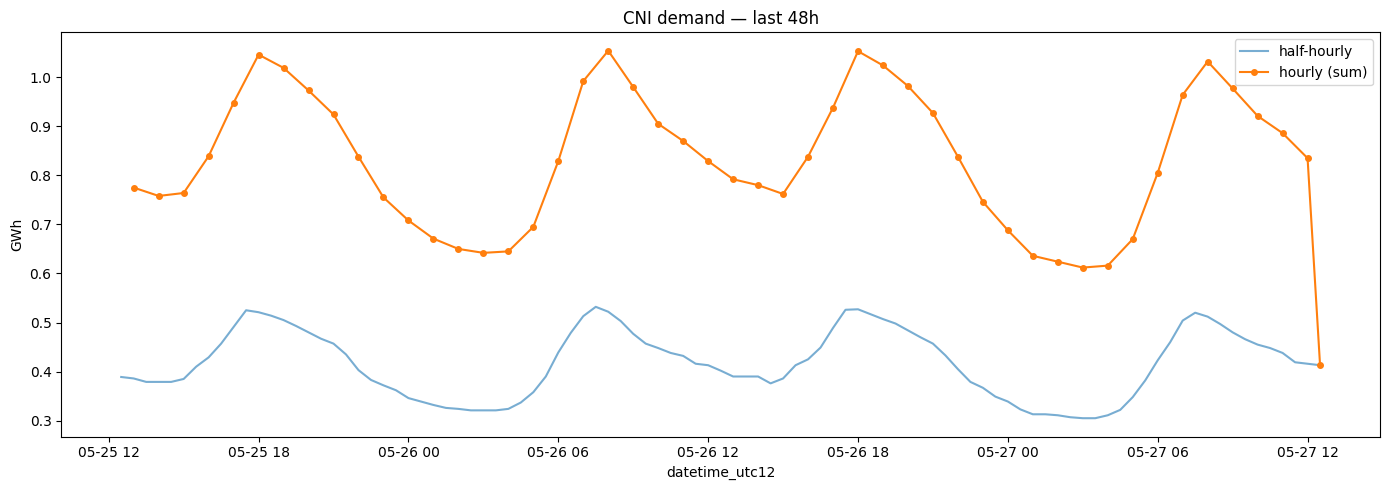

In [11]:
import matplotlib.pyplot as plt

col_hh = 'demand_GWh_CNI'
col_h  = 'demand_GWh_CNI'

def plot_window(label, mask_hh, mask_h):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df[mask_hh]['datetime'], df[mask_hh][col_hh], label='half-hourly', alpha=0.6)
    ax.plot(df_hourly_demand[mask_h]['datetime_utc12'], df_hourly_demand[mask_h][col_h], label='hourly (sum)', marker='o', markersize=4)
    ax.set_title(f'CNI demand — {label}')
    ax.set_xlabel('datetime_utc12')
    ax.set_ylabel('GWh')
    ax.legend()
    plt.tight_layout()
    plt.show()

# First 48h
mask_hh_start = df['datetime'] < df['datetime'].min() + pd.Timedelta(hours=48)
mask_h_start  = df_hourly_demand['datetime_utc12'] < df_hourly_demand['datetime_utc12'].min() + pd.Timedelta(hours=48)

# Middle
mid_hh = df['datetime'].min() + (df['datetime'].max() - df['datetime'].min()) / 2
mid_h  = df_hourly_demand['datetime_utc12'].min() + (df_hourly_demand['datetime_utc12'].max() - df_hourly_demand['datetime_utc12'].min()) / 2

mask_hh_mid = (df['datetime'] >= mid_hh) & (df['datetime'] < mid_hh + pd.Timedelta(hours=48))
mask_h_mid  = (df_hourly_demand['datetime_utc12'] >= mid_h) & (df_hourly_demand['datetime_utc12'] < mid_h + pd.Timedelta(hours=48))

# End
mask_hh_end = df['datetime'] >= df['datetime'].max() - pd.Timedelta(hours=48)
mask_h_end  = df_hourly_demand['datetime_utc12'] >= df_hourly_demand['datetime_utc12'].max() - pd.Timedelta(hours=48)

plot_window('first 48h',  mask_hh_start, mask_h_start)
plot_window('middle 48h', mask_hh_mid,   mask_h_mid)
plot_window('last 48h',   mask_hh_end,   mask_h_end)